In [24]:
datasets_folder = "datasets/csvs/"
graphs_folder = "graphs/"
measures_folder = "measures/"
plots_folder = "plots/latex/"

# Horas críticas (Beiró & Gandica et al.)
HORA_CRITICA_NAT, HORA_CRITICA_9N, HORA_CRITICA_CH = "429624", "437037", "394717"
hour_window_nat, hour_window_9n, hour_window_ch = 1, 2, 2

limites = True

In [25]:
import os
from collections import Counter, defaultdict
from math import comb

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from networkx.algorithms.community import louvain_communities
from tqdm.auto import tqdm

plt.style.use("seaborn-v0_8-colorblind")

try:
    from sklearn.metrics import adjusted_mutual_info_score
except ImportError:
    def _entropy_from_labels(labels):
        n = len(labels)
        counts = Counter(labels)
        return -sum((c / n) * np.log(c / n) for c in counts.values())

    def _contingency_matrix(y_true, y_pred):
        classes_true = {c: i for i, c in enumerate(np.unique(y_true))}
        classes_pred = {c: i for i, c in enumerate(np.unique(y_pred))}
        cont = np.zeros((len(classes_true), len(classes_pred)), dtype=np.float64)
        for t, p in zip(y_true, y_pred):
            cont[classes_true[t], classes_pred[p]] += 1
        return cont

    def _expected_mutual_information(contingency):
        n = contingency.sum()
        if n == 0:
            return 0.0
        row_sum = contingency.sum(axis=1)
        col_sum = contingency.sum(axis=0)
        emi = 0.0
        for i in range(contingency.shape[0]):
            for j in range(contingency.shape[1]):
                n_ij = contingency[i, j]
                if n_ij == 0:
                    continue
                emi += (n_ij / n) * np.log(
                    (n * n_ij) / (row_sum[i] * col_sum[j] + 1e-12)
                )
        return emi

    def adjusted_mutual_info_score(y_true, y_pred):
        y_true = np.asarray(y_true)
        y_pred = np.asarray(y_pred)
        cont = _contingency_matrix(y_true, y_pred)
        n = cont.sum()
        if n == 0:
            return 1.0
        outer = np.outer(cont.sum(axis=1), cont.sum(axis=0))
        mi = 0.0
        for i in range(cont.shape[0]):
            for j in range(cont.shape[1]):
                n_ij = cont[i, j]
                if n_ij == 0:
                    continue
                mi += (n_ij / n) * np.log((n * n_ij) / (outer[i, j] + 1e-12))
        emi = _expected_mutual_information(cont)
        h_true = _entropy_from_labels(y_true)
        h_pred = _entropy_from_labels(y_pred)
        normalizer = 0.5 * (h_true + h_pred)
        denom = normalizer - emi
        if abs(denom) < 1e-12:
            return 1.0 if np.array_equal(y_true, y_pred) else 0.0
        return (mi - emi) / denom

EPSILON_BASE = "epsilon_sq/"
LOUVAIN_SEED = 42

HOUR_RANGES = {
    "nat": (429576, 429672),
    "9n": (int(HORA_CRITICA_9N) - 72, int(HORA_CRITICA_9N) + 72),
    "ch": (int(HORA_CRITICA_CH) - 48, int(HORA_CRITICA_CH) + 48),
}

MANIFESTACIONES = {
    "nat": {"hora_critica": HORA_CRITICA_NAT, "hour_window": hour_window_nat},
    "9n": {"hora_critica": HORA_CRITICA_9N, "hour_window": hour_window_9n},
    "ch": {"hora_critica": HORA_CRITICA_CH, "hour_window": hour_window_ch},
}

PLOT_LIMITS_REL = {
    m: (
        (HOUR_RANGES[m][0] - int(cfg["hora_critica"])) / cfg["hour_window"],
        (HOUR_RANGES[m][1] - int(cfg["hora_critica"])) / cfg["hour_window"],
    )
    for m, cfg in MANIFESTACIONES.items()
}

os.makedirs(plots_folder, exist_ok=True)

In [26]:
def load_graph(manifestacion, hora):
    path = f"{EPSILON_BASE}{manifestacion}/{hora}/{hora}.edge"
    if not os.path.exists(path) or os.path.getsize(path) == 0:
        return None
    g = nx.read_edgelist(path, data=False)
    g.remove_edges_from(nx.selfloop_edges(g))
    return g


def louvain_partition(g, seed=LOUVAIN_SEED):
    if g is None or g.number_of_nodes() == 0:
        return {}
    communities = louvain_communities(g, seed=seed)
    partition = {}
    for idx, comm in enumerate(communities):
        for node in comm:
            partition[node] = idx
    return partition


def list_hours(manifestacion, hora_range=None):
    base = f"{EPSILON_BASE}{manifestacion}/"
    hours = []
    for name in os.listdir(base):
        if not name.isdigit():
            continue
        h = int(name)
        if hora_range is not None:
            h0, h1 = hora_range
            if h < h0 or h >= h1:
                continue
        edge = f"{base}{name}/{name}.edge"
        if os.path.isfile(edge) and os.path.getsize(edge) > 0:
            hours.append(name)
    return sorted(hours, key=int)


def labels_for_ami(partition_ref, partition_h, nodes):
    labels_ref = [partition_ref[n] for n in nodes]
    max_h = max(partition_h.values(), default=-1)
    labels_h = []
    next_singleton = max_h + 1
    for n in nodes:
        if n in partition_h:
            labels_h.append(partition_h[n])
        else:
            labels_h.append(next_singleton)
            next_singleton += 1
    return labels_ref, labels_h


def pairwise_comembership(partition_ref, partition_h, nodes):
    ref_clusters = defaultdict(list)
    for n in nodes:
        ref_clusters[partition_ref[n]].append(n)

    denom = sum(comb(len(members), 2) for members in ref_clusters.values())
    if denom == 0:
        return 1.0

    numer = 0
    for members in ref_clusters.values():
        by_h = defaultdict(int)
        for n in members:
            if n in partition_h:
                by_h[partition_h[n]] += 1
        numer += sum(comb(c, 2) for c in by_h.values())
    return numer / denom


def compute_metrics_for_manifestacion(manifestacion, cfg):
    hora_critica = cfg["hora_critica"]
    hour_window = cfg["hour_window"]

    g_ref = load_graph(manifestacion, hora_critica)
    if g_ref is None:
        raise FileNotFoundError(
            f"No se encontró el grafo de la hora crítica: {manifestacion}/{hora_critica}"
        )

    partition_ref = louvain_partition(g_ref)
    nodes_ref = list(partition_ref.keys())
    hora_critica_int = int(hora_critica)

    rows = []
    hora_range = HOUR_RANGES[manifestacion]
    for hora in tqdm(
        list_hours(manifestacion, hora_range=hora_range),
        desc=f"{manifestacion.upper()}",
    ):
        g_h = load_graph(manifestacion, hora)
        partition_h = louvain_partition(g_h) if g_h is not None else {}

        labels_ref, labels_h = labels_for_ami(partition_ref, partition_h, nodes_ref)
        ami = adjusted_mutual_info_score(labels_ref, labels_h)
        pairwise = pairwise_comembership(partition_ref, partition_h, nodes_ref)

        rows.append(
            {
                "manifestacion": manifestacion,
                "hour": int(hora),
                "hour_rel": (int(hora) - hora_critica_int) / hour_window,
                "ami": ami,
                "pairwise": pairwise,
            }
        )

    return pd.DataFrame(rows)

In [27]:
results = []
for manifestacion, cfg in MANIFESTACIONES.items():
    results.append(compute_metrics_for_manifestacion(manifestacion, cfg))

df_ami = pd.concat(results, ignore_index=True)
df_ami.to_csv(f"{measures_folder}ami_louvain_vs_critica.csv", index=False)
df_ami.head()

NAT:   0%|          | 0/96 [00:00<?, ?it/s]

CH: 100%|██████████| 91/91 [00:02<00:00, 42.36it/s]


,manifestacion,hour,hour_rel,ami,pairwise
0,nat,429576,-48.0,0.0,0.003123
1,nat,429577,-47.0,0.0,0.002541
2,nat,429578,-46.0,0.0,0.004288
3,nat,429579,-45.0,0.0,0.002594
4,nat,429580,-44.0,0.0,0.000900


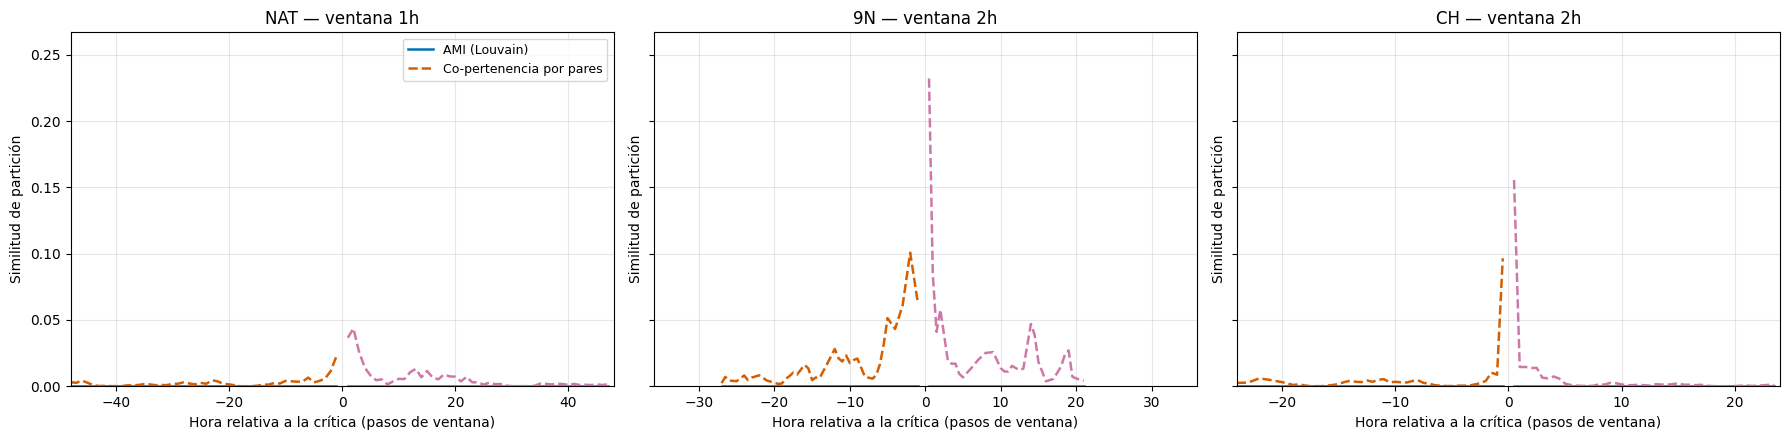

Guardado en plots/latex/ami_louvain_vs_critica.png


In [28]:
plot_frames = []
for manifestacion, cfg in MANIFESTACIONES.items():
    df_m = df_ami[df_ami["manifestacion"] == manifestacion].sort_values("hour_rel")

    if limites:
        x_min, x_max = PLOT_LIMITS_REL[manifestacion]
        df_m = df_m[(df_m["hour_rel"] >= x_min) & (df_m["hour_rel"] <= x_max)]
    else:
        x_min, x_max = df_m["hour_rel"].min(), df_m["hour_rel"].max()

    plot_frames.append((manifestacion, cfg, df_m, x_min, x_max))

ymax = max(
    max(
        df_m.loc[df_m["hour_rel"] != 0, "ami"].max(),
        df_m.loc[df_m["hour_rel"] != 0, "pairwise"].max(),
    )
    for _, _, df_m, _, _ in plot_frames
) * 1.15

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharey=True)

for ax, (manifestacion, cfg, df_m, x_min, x_max) in zip(axes, plot_frames):
    hour_window = cfg["hour_window"]
    df_before = df_m[df_m["hour_rel"] < 0]
    df_after = df_m[df_m["hour_rel"] > 0]

    ax.plot(df_before["hour_rel"], df_before["ami"], label="AMI (Louvain)", linewidth=1.8)
    ax.plot(df_after["hour_rel"], df_after["ami"], linewidth=1.8)
    ax.plot(
        df_before["hour_rel"],
        df_before["pairwise"],
        label="Co-pertenencia por pares",
        linewidth=1.8,
        linestyle="--",
    )
    ax.plot(df_after["hour_rel"], df_after["pairwise"], linewidth=1.8, linestyle="--")

    ax.set_xlim(x_min, x_max)
    ax.set_title(f"{manifestacion.upper()} — ventana {hour_window}h")
    ax.set_xlabel("Hora relativa a la crítica (pasos de ventana)")
    ax.set_ylabel("Similitud de partición")
    ax.set_ylim(0, ymax)
    ax.grid(alpha=0.3)

axes[0].legend(loc="upper right", fontsize=9)
plt.tight_layout()

out_path = f"{plots_folder}ami_louvain_vs_critica.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Guardado en {out_path}")

CH paper-style AMI: 100%|██████████| 91/91 [00:03<00:00, 25.78it/s]


,manifestacion,hour,hour_rel,layer_abs,ami_paper_style,n_nodes_ref,n_edges_layer,n_comms_ref,n_comms_layer
0,nat,429576,-48.0,48.0,0.0,592,148,34,533
1,nat,429577,-47.0,47.0,0.0,592,152,34,537
2,nat,429578,-46.0,46.0,0.0,592,129,34,549
3,nat,429579,-45.0,45.0,0.0,592,90,34,562
4,nat,429580,-44.0,44.0,0.0,592,43,34,576


/tmp/ipykernel_78060/1833850415.py:243: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(0, ymax)


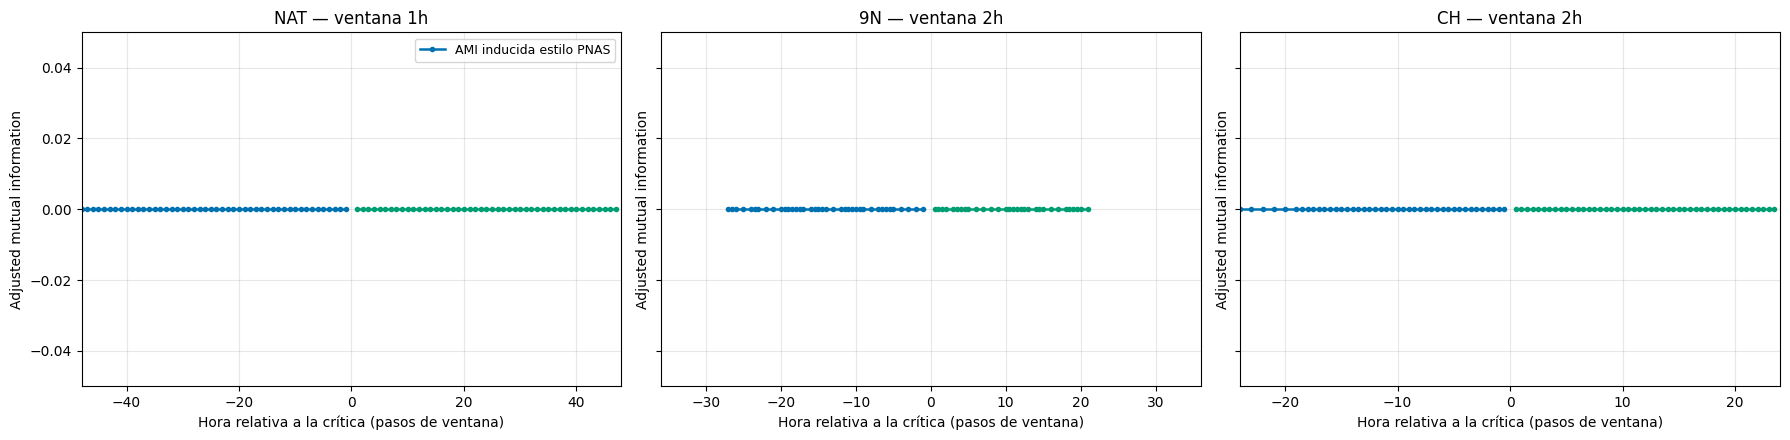

CSV guardado en: measures/ami_pnas_style_vs_critica.csv
Figura guardada en: plots/latex/ami_pnas_style_vs_critica.png


In [29]:
# ============================================================
# AMI estilo PNAS:
# partición de la "capa 0" = hora crítica
# vs particiones inducidas por cada otra "capa" temporal
# ============================================================

os.makedirs(measures_folder, exist_ok=True)
os.makedirs(plots_folder, exist_ok=True)

# Usa el mismo universo de nodos para comparar particiones.
# "critica": usa los nodos presentes en la hora crítica.
# "union_rango": usa la unión de nodos de todas las horas del rango.
PAPER_NODE_UNIVERSE = "critica"  # cambia a "union_rango" si quieres incluir nodos activos fuera de la crítica

# Eje tipo paper:
# False -> x = hour_rel firmado (antes y después de la crítica), como el plot anterior
# True  -> x = distancia absoluta a la crítica, promediando antes/después
PLOT_AS_LAYER_DISTANCE = False


def node_universe_for_manifestacion(manifestacion, cfg, hours, mode="critica"):
    """
    Define el conjunto fijo de objetos sobre el que se comparan las particiones.
    En el paper, todas las particiones se comparan sobre la capa original.
    Aquí usamos la hora crítica como análogo de esa capa original.
    """
    if mode == "union_rango":
        nodes = set()
        for hora in hours:
            g = load_graph(manifestacion, hora)
            if g is not None:
                nodes.update(g.nodes())
        if not nodes:
            raise ValueError(f"No hay nodos disponibles para {manifestacion}")
        return sorted(nodes)

    if mode == "critica":
        g0 = load_graph(manifestacion, cfg["hora_critica"])
        if g0 is None:
            raise FileNotFoundError(
                f"No se encontró el grafo crítico: {manifestacion}/{cfg['hora_critica']}"
            )
        return sorted(g0.nodes())

    raise ValueError("PAPER_NODE_UNIVERSE debe ser 'critica' o 'union_rango'")


def graph_projected_to_reference_nodes(manifestacion, hora, nodes_ref):
    """
    Construye la capa/hora sobre el mismo universo de nodos de referencia.
    Los nodos sin aristas en esa hora quedan como aislados, en lugar de desaparecer.
    Esto evita comparar particiones sobre conjuntos distintos.
    """
    g = load_graph(manifestacion, hora)

    if g is None:
        g = nx.Graph()
    else:
        # Nos quedamos solo con los objetos de la capa de referencia.
        # Esto imita la comparación sobre la capa original del paper.
        g = g.subgraph(nodes_ref).copy()

    g.add_nodes_from(nodes_ref)
    g.remove_edges_from(nx.selfloop_edges(g))
    return g


def labels_from_partition(partition, nodes):
    """
    Devuelve etiquetas alineadas con nodes.
    Si por alguna razón Louvain no devuelve algún nodo, se lo trata como singleton.
    """
    labels = []
    next_singleton = max(partition.values(), default=-1) + 1

    for n in nodes:
        if n in partition:
            labels.append(partition[n])
        else:
            labels.append(next_singleton)
            next_singleton += 1

    return labels


def compute_paper_style_ami_for_manifestacion(
    manifestacion,
    cfg,
    node_universe_mode=PAPER_NODE_UNIVERSE,
):
    hora_critica = cfg["hora_critica"]
    hora_critica_int = int(hora_critica)
    hour_window = cfg["hour_window"]

    hours = list_hours(manifestacion, hora_range=HOUR_RANGES[manifestacion])

    # Asegura que la hora crítica esté incluida, para que la curva tenga l=0, AMI=1.
    if hora_critica not in hours:
        hours = sorted(set(hours + [hora_critica]), key=int)

    nodes_ref = node_universe_for_manifestacion(
        manifestacion,
        cfg,
        hours,
        mode=node_universe_mode,
    )

    # Capa 0 / referencia: hora crítica.
    g0 = graph_projected_to_reference_nodes(manifestacion, hora_critica, nodes_ref)
    partition0 = louvain_partition(g0)
    labels0 = labels_from_partition(partition0, nodes_ref)

    rows = []

    for hora in tqdm(hours, desc=f"{manifestacion.upper()} paper-style AMI"):
        g_h = graph_projected_to_reference_nodes(manifestacion, hora, nodes_ref)
        partition_h = louvain_partition(g_h)

        # Partición "inducida" sobre la capa 0.
        # Como no hay mapa geométrico de coarse-graining en tus datos,
        # la inducción se hace por identidad sobre los nodos de referencia.
        labels_h_induced = labels_from_partition(partition_h, nodes_ref)

        ami_paper_style = adjusted_mutual_info_score(labels0, labels_h_induced)

        hour_rel = (int(hora) - hora_critica_int) / hour_window

        rows.append(
            {
                "manifestacion": manifestacion,
                "hour": int(hora),
                "hour_rel": hour_rel,
                "layer_abs": abs(hour_rel),
                "ami_paper_style": ami_paper_style,
                "n_nodes_ref": len(nodes_ref),
                "n_edges_layer": g_h.number_of_edges(),
                "n_comms_ref": len(set(labels0)),
                "n_comms_layer": len(set(labels_h_induced)),
            }
        )

    return pd.DataFrame(rows)


# -------------------------
# Cálculo
# -------------------------

paper_style_results = []

for manifestacion, cfg in MANIFESTACIONES.items():
    paper_style_results.append(
        compute_paper_style_ami_for_manifestacion(
            manifestacion,
            cfg,
            node_universe_mode=PAPER_NODE_UNIVERSE,
        )
    )

df_ami_paper = pd.concat(paper_style_results, ignore_index=True)

out_csv = f"{measures_folder}ami_pnas_style_vs_critica.csv"
df_ami_paper.to_csv(out_csv, index=False)

display(df_ami_paper.head())


# -------------------------
# Curva (misma lógica de visualización que el plot anterior)
# -------------------------

if PLOT_AS_LAYER_DISTANCE:
    df_plot = (
        df_ami_paper
        .groupby(["manifestacion", "layer_abs"], as_index=False)
        .agg(
            ami_paper_style=("ami_paper_style", "mean"),
            n_points=("ami_paper_style", "size"),
        )
        .sort_values(["manifestacion", "layer_abs"])
    )

    plot_frames = []
    for manifestacion, cfg in MANIFESTACIONES.items():
        df_m = df_plot[df_plot["manifestacion"] == manifestacion].sort_values("layer_abs")
        df_m = df_m[df_m["layer_abs"] != 0]

        if limites:
            x_min, x_max = 1, PLOT_LIMITS_REL[manifestacion][1]
            df_m = df_m[(df_m["layer_abs"] >= x_min) & (df_m["layer_abs"] <= x_max)]
        else:
            x_min, x_max = df_m["layer_abs"].min(), df_m["layer_abs"].max()

        plot_frames.append((manifestacion, cfg, df_m, x_min, x_max, "layer_abs"))

    x_label = r"Capa $l$ = distancia a la hora crítica (en ventanas)"
else:
    plot_frames = []
    for manifestacion, cfg in MANIFESTACIONES.items():
        df_m = df_ami_paper[df_ami_paper["manifestacion"] == manifestacion].sort_values("hour_rel")

        if limites:
            x_min, x_max = PLOT_LIMITS_REL[manifestacion]
            df_m = df_m[(df_m["hour_rel"] >= x_min) & (df_m["hour_rel"] <= x_max)]
        else:
            x_min, x_max = df_m["hour_rel"].min(), df_m["hour_rel"].max()

        plot_frames.append((manifestacion, cfg, df_m, x_min, x_max, "hour_rel"))

    x_label = "Hora relativa a la crítica (pasos de ventana)"

ymax = max(
    df_m.loc[df_m[x_col] != 0, "ami_paper_style"].max()
    for _, _, df_m, _, _, x_col in plot_frames
) * 1.15

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharey=True)

for ax, (manifestacion, cfg, df_m, x_min, x_max, x_col) in zip(axes, plot_frames):
    df_before = df_m[df_m[x_col] < 0]
    df_after = df_m[df_m[x_col] > 0]

    ax.plot(
        df_before[x_col],
        df_before["ami_paper_style"],
        label="AMI inducida estilo PNAS",
        linewidth=1.8,
        marker="o",
        markersize=3,
    )
    ax.plot(
        df_after[x_col],
        df_after["ami_paper_style"],
        linewidth=1.8,
        marker="o",
        markersize=3,
    )

    ax.set_xlim(x_min, x_max)
    ax.set_title(f"{manifestacion.upper()} — ventana {cfg['hour_window']}h")
    ax.set_xlabel(x_label)
    ax.set_ylabel("Adjusted mutual information")
    ax.set_ylim(0, ymax)
    ax.grid(alpha=0.3)

axes[0].legend(loc="upper right", fontsize=9)
plt.tight_layout()

out_path = f"{plots_folder}ami_pnas_style_vs_critica.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"CSV guardado en: {out_csv}")
print(f"Figura guardada en: {out_path}")

CH LCC: 100%|██████████| 91/91 [00:01<00:00, 49.46it/s]


,manifestacion,hour,hour_rel,ami,pairwise,n_nodes_ref,n_nodes_layer
0,nat,429576,-48.0,0.0,0.003618,538,332
1,nat,429577,-47.0,0.0,0.002714,538,338
2,nat,429578,-46.0,0.0,0.004332,538,248
3,nat,429579,-45.0,0.0,0.002047,538,184
4,nat,429580,-44.0,0.0,0.001047,538,70


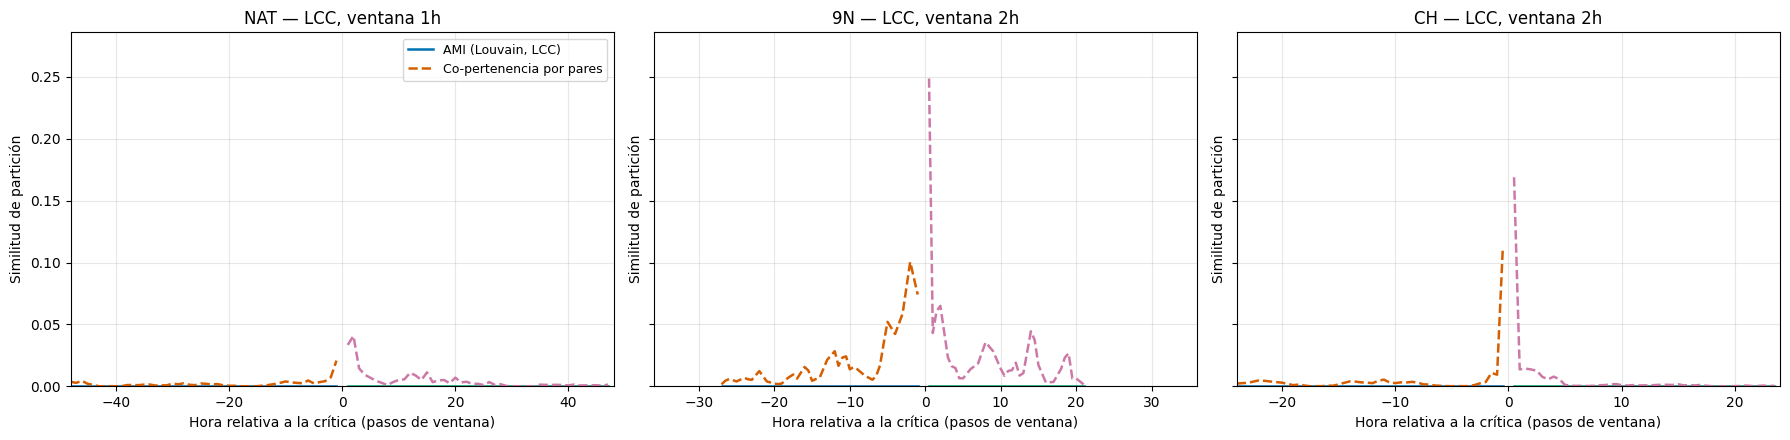

Guardado en plots/latex/ami_lcc_vs_critica.png


In [30]:
# Restringir a la componente conexa mayor (LCC)


def largest_connected_component(g):
    if g is None or g.number_of_nodes() == 0:
        return None
    if g.number_of_edges() == 0:
        return g.copy()
    largest = max(nx.connected_components(g), key=len)
    return g.subgraph(largest).copy()


def compute_metrics_lcc(manifestacion, cfg):
    hora_critica = cfg["hora_critica"]
    hour_window = cfg["hour_window"]
    hora_critica_int = int(hora_critica)

    g_ref = largest_connected_component(load_graph(manifestacion, hora_critica))
    if g_ref is None or g_ref.number_of_nodes() == 0:
        raise FileNotFoundError(
            f"No se encontró la LCC de la hora crítica: {manifestacion}/{hora_critica}"
        )

    partition_ref = louvain_partition(g_ref)
    nodes_ref = list(g_ref.nodes())

    rows = []
    hora_range = HOUR_RANGES[manifestacion]
    for hora in tqdm(
        list_hours(manifestacion, hora_range=hora_range),
        desc=f"{manifestacion.upper()} LCC",
    ):
        g_h = largest_connected_component(load_graph(manifestacion, hora))
        partition_h = louvain_partition(g_h) if g_h is not None else {}

        labels_ref, labels_h = labels_for_ami(partition_ref, partition_h, nodes_ref)
        ami = adjusted_mutual_info_score(labels_ref, labels_h)
        pairwise = pairwise_comembership(partition_ref, partition_h, nodes_ref)

        rows.append(
            {
                "manifestacion": manifestacion,
                "hour": int(hora),
                "hour_rel": (int(hora) - hora_critica_int) / hour_window,
                "ami": ami,
                "pairwise": pairwise,
                "n_nodes_ref": len(nodes_ref),
                "n_nodes_layer": g_h.number_of_nodes() if g_h is not None else 0,
            }
        )

    return pd.DataFrame(rows)


results_lcc = [
    compute_metrics_lcc(manifestacion, cfg)
    for manifestacion, cfg in MANIFESTACIONES.items()
]
df_ami_lcc = pd.concat(results_lcc, ignore_index=True)
df_ami_lcc.to_csv(f"{measures_folder}ami_lcc_vs_critica.csv", index=False)
display(df_ami_lcc.head())

plot_frames = []
for manifestacion, cfg in MANIFESTACIONES.items():
    df_m = df_ami_lcc[df_ami_lcc["manifestacion"] == manifestacion].sort_values("hour_rel")

    if limites:
        x_min, x_max = PLOT_LIMITS_REL[manifestacion]
        df_m = df_m[(df_m["hour_rel"] >= x_min) & (df_m["hour_rel"] <= x_max)]
    else:
        x_min, x_max = df_m["hour_rel"].min(), df_m["hour_rel"].max()

    plot_frames.append((manifestacion, cfg, df_m, x_min, x_max))

ymax = max(
    max(
        df_m.loc[df_m["hour_rel"] != 0, "ami"].max(),
        df_m.loc[df_m["hour_rel"] != 0, "pairwise"].max(),
    )
    for _, _, df_m, _, _ in plot_frames
) * 1.15

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharey=True)

for ax, (manifestacion, cfg, df_m, x_min, x_max) in zip(axes, plot_frames):
    hour_window = cfg["hour_window"]
    df_before = df_m[df_m["hour_rel"] < 0]
    df_after = df_m[df_m["hour_rel"] > 0]

    ax.plot(df_before["hour_rel"], df_before["ami"], label="AMI (Louvain, LCC)", linewidth=1.8)
    ax.plot(df_after["hour_rel"], df_after["ami"], linewidth=1.8)
    ax.plot(
        df_before["hour_rel"],
        df_before["pairwise"],
        label="Co-pertenencia por pares",
        linewidth=1.8,
        linestyle="--",
    )
    ax.plot(df_after["hour_rel"], df_after["pairwise"], linewidth=1.8, linestyle="--")

    ax.set_xlim(x_min, x_max)
    ax.set_title(f"{manifestacion.upper()} — LCC, ventana {hour_window}h")
    ax.set_xlabel("Hora relativa a la crítica (pasos de ventana)")
    ax.set_ylabel("Similitud de partición")
    ax.set_ylim(0, ymax)
    ax.grid(alpha=0.3)

axes[0].legend(loc="upper right", fontsize=9)
plt.tight_layout()

out_path = f"{plots_folder}ami_lcc_vs_critica.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Guardado en {out_path}")

CH intersección: 100%|██████████| 91/91 [00:01<00:00, 53.39it/s]


,manifestacion,hour,hour_rel,ami,pairwise,n_nodes_common,n_nodes_ref
0,nat,429576,-48.0,0.0,0.120902,91,592
1,nat,429577,-47.0,0.0,0.117073,84,592
2,nat,429578,-46.0,0.0,0.236842,70,592
3,nat,429579,-45.0,0.0,0.191406,61,592
4,nat,429580,-44.0,0.0,0.186813,34,592


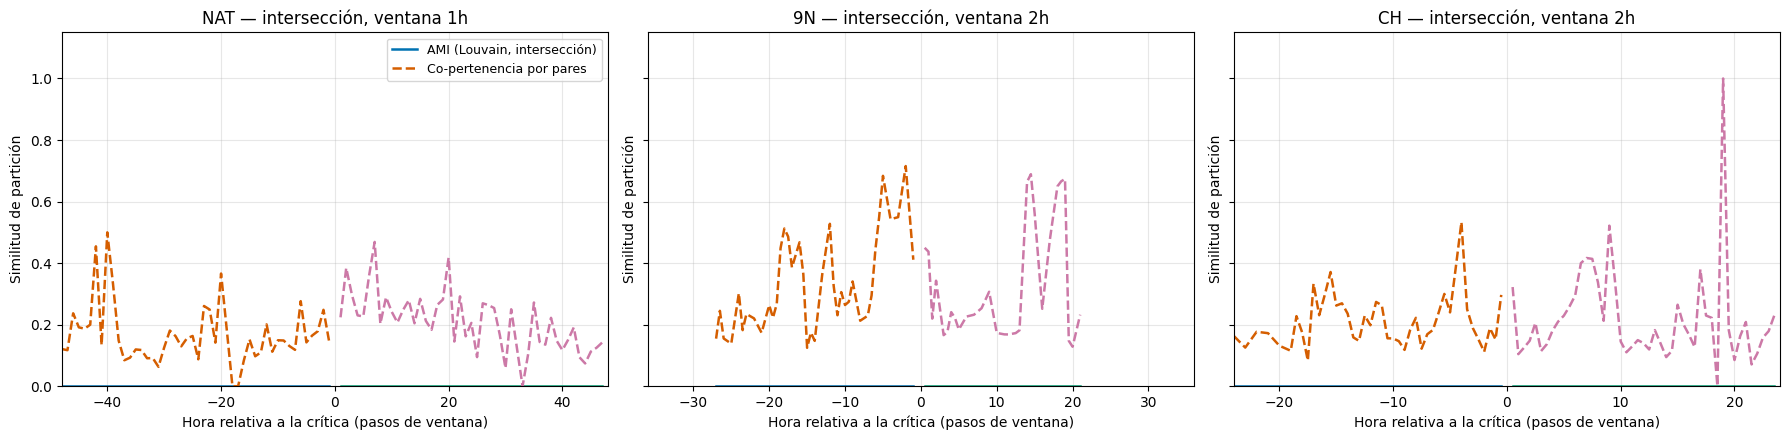

Guardado en plots/latex/ami_intersection_vs_critica.png


In [31]:
# Comparar solo nodos presentes en ambas horas (intersección)


def compute_metrics_intersection(manifestacion, cfg):
    hora_critica = cfg["hora_critica"]
    hour_window = cfg["hour_window"]
    hora_critica_int = int(hora_critica)

    g_ref = load_graph(manifestacion, hora_critica)
    if g_ref is None:
        raise FileNotFoundError(
            f"No se encontró el grafo de la hora crítica: {manifestacion}/{hora_critica}"
        )

    partition_ref = louvain_partition(g_ref)
    nodes_ref = set(partition_ref.keys())

    rows = []
    hora_range = HOUR_RANGES[manifestacion]
    for hora in tqdm(
        list_hours(manifestacion, hora_range=hora_range),
        desc=f"{manifestacion.upper()} intersección",
    ):
        g_h = load_graph(manifestacion, hora)
        if g_h is None:
            partition_h = {}
            nodes_common = []
        else:
            partition_h = louvain_partition(g_h)
            nodes_common = sorted(nodes_ref & set(g_h.nodes()), key=str)

        if len(nodes_common) < 2:
            ami, pairwise = 0.0, 0.0
        else:
            labels_ref = [partition_ref[n] for n in nodes_common]
            labels_h = [partition_h[n] for n in nodes_common]
            ami = adjusted_mutual_info_score(labels_ref, labels_h)
            pairwise = pairwise_comembership(partition_ref, partition_h, nodes_common)

        rows.append(
            {
                "manifestacion": manifestacion,
                "hour": int(hora),
                "hour_rel": (int(hora) - hora_critica_int) / hour_window,
                "ami": ami,
                "pairwise": pairwise,
                "n_nodes_common": len(nodes_common),
                "n_nodes_ref": len(nodes_ref),
            }
        )

    return pd.DataFrame(rows)


results_intersection = [
    compute_metrics_intersection(manifestacion, cfg)
    for manifestacion, cfg in MANIFESTACIONES.items()
]
df_ami_intersection = pd.concat(results_intersection, ignore_index=True)
df_ami_intersection.to_csv(f"{measures_folder}ami_intersection_vs_critica.csv", index=False)
display(df_ami_intersection.head())

plot_frames = []
for manifestacion, cfg in MANIFESTACIONES.items():
    df_m = df_ami_intersection[
        df_ami_intersection["manifestacion"] == manifestacion
    ].sort_values("hour_rel")

    if limites:
        x_min, x_max = PLOT_LIMITS_REL[manifestacion]
        df_m = df_m[(df_m["hour_rel"] >= x_min) & (df_m["hour_rel"] <= x_max)]
    else:
        x_min, x_max = df_m["hour_rel"].min(), df_m["hour_rel"].max()

    plot_frames.append((manifestacion, cfg, df_m, x_min, x_max))

ymax = max(
    max(
        df_m.loc[df_m["hour_rel"] != 0, "ami"].max(),
        df_m.loc[df_m["hour_rel"] != 0, "pairwise"].max(),
    )
    for _, _, df_m, _, _ in plot_frames
) * 1.15

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharey=True)

for ax, (manifestacion, cfg, df_m, x_min, x_max) in zip(axes, plot_frames):
    hour_window = cfg["hour_window"]
    df_before = df_m[df_m["hour_rel"] < 0]
    df_after = df_m[df_m["hour_rel"] > 0]

    ax.plot(
        df_before["hour_rel"],
        df_before["ami"],
        label="AMI (Louvain, intersección)",
        linewidth=1.8,
    )
    ax.plot(df_after["hour_rel"], df_after["ami"], linewidth=1.8)
    ax.plot(
        df_before["hour_rel"],
        df_before["pairwise"],
        label="Co-pertenencia por pares",
        linewidth=1.8,
        linestyle="--",
    )
    ax.plot(df_after["hour_rel"], df_after["pairwise"], linewidth=1.8, linestyle="--")

    ax.set_xlim(x_min, x_max)
    ax.set_title(f"{manifestacion.upper()} — intersección, ventana {hour_window}h")
    ax.set_xlabel("Hora relativa a la crítica (pasos de ventana)")
    ax.set_ylabel("Similitud de partición")
    ax.set_ylim(0, ymax)
    ax.grid(alpha=0.3)

axes[0].legend(loc="upper right", fontsize=9)
plt.tight_layout()

out_path = f"{plots_folder}ami_intersection_vs_critica.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Guardado en {out_path}")

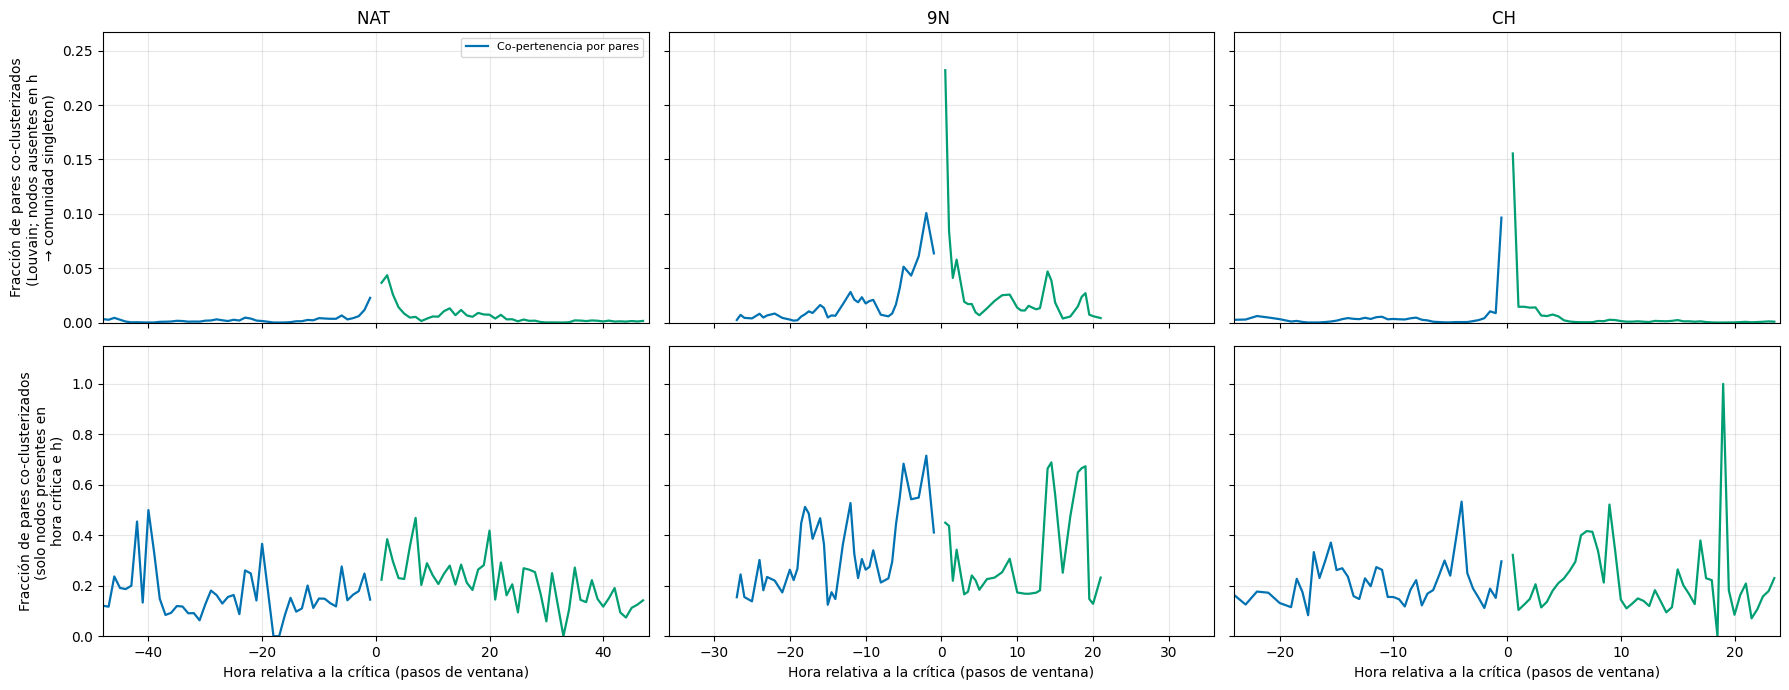

Guardado en plots/latex/ami_all_methods_vs_critica.png


In [36]:
# Panel combinado: filas = método de cálculo, columnas = manifestación (nat / 9n / ch)

MANIFESTACION_ORDER = list(MANIFESTACIONES.keys())

AMI_PANELS = [
    (
        "Fracción de pares co-clusterizados\n"
        "(Louvain; nodos ausentes en h \n→ comunidad singleton)",
        df_ami,
        False,
        True,
    ),
    (
        "Fracción de pares co-clusterizados\n"
        "(solo nodos presentes en \nhora crítica e h)",
        df_ami_intersection,
        False,
        True,
    ),
]


def _frame_for_manifestacion(df, manifestacion):
    df_m = df[df["manifestacion"] == manifestacion].sort_values("hour_rel")
    if limites:
        x_min, x_max = PLOT_LIMITS_REL[manifestacion]
        df_m = df_m[(df_m["hour_rel"] >= x_min) & (df_m["hour_rel"] <= x_max)]
    else:
        x_min, x_max = df_m["hour_rel"].min(), df_m["hour_rel"].max()
    return df_m, x_min, x_max


def _plot_discontinuous(ax, df_m, x_min, x_max, show_ami, show_pairwise):
    df_before = df_m[df_m["hour_rel"] < 0]
    df_after = df_m[df_m["hour_rel"] > 0]

    if show_ami:
        ax.plot(
            df_before["hour_rel"],
            df_before["ami"],
            label="AMI (Louvain)",
            linewidth=1.6,
        )
        ax.plot(df_after["hour_rel"], df_after["ami"], linewidth=1.6)

    if show_pairwise:
        ax.plot(
            df_before["hour_rel"],
            df_before["pairwise"],
            label="Co-pertenencia por pares",
            linewidth=1.6,
            linestyle="--" if show_ami else "-",
        )
        ax.plot(
            df_after["hour_rel"],
            df_after["pairwise"],
            linewidth=1.6,
            linestyle="--" if show_ami else "-",
        )

    ax.set_xlim(x_min, x_max)
    ax.grid(alpha=0.3)


n_rows = len(AMI_PANELS)
n_cols = len(MANIFESTACION_ORDER)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 7), sharex="col", sharey="row")

if n_rows == 1:
    axes = np.array([axes])
if n_cols == 1:
    axes = axes.reshape(-1, 1)

for row_idx, (row_ylabel, df_panel, show_ami, show_pairwise) in enumerate(AMI_PANELS):
    row_ymax = 0.0
    row_frames = []

    for manifestacion in MANIFESTACION_ORDER:
        df_m, x_min, x_max = _frame_for_manifestacion(df_panel, manifestacion)
        row_frames.append((manifestacion, df_m, x_min, x_max))
        vals = []
        if show_ami:
            vals.append(df_m.loc[df_m["hour_rel"] != 0, "ami"].max())
        if show_pairwise:
            vals.append(df_m.loc[df_m["hour_rel"] != 0, "pairwise"].max())
        row_ymax = max(row_ymax, *vals)

    row_ymax = max(row_ymax * 1.15, 0.05)

    for col_idx, manifestacion in enumerate(MANIFESTACION_ORDER):
        ax = axes[row_idx, col_idx]
        cfg = MANIFESTACIONES[manifestacion]
        _, df_m, x_min, x_max = row_frames[col_idx]

        _plot_discontinuous(ax, df_m, x_min, x_max, show_ami, show_pairwise)

        ax.set_ylim(0, row_ymax)

        if row_idx == 0:
            ax.set_title(f"{manifestacion.upper()} ")
        if col_idx == 0:
            ax.set_ylabel(row_ylabel)
        if row_idx == n_rows - 1:
            ax.set_xlabel("Hora relativa a la crítica (pasos de ventana)")

axes[0, 0].legend(loc="upper right", fontsize=8)
plt.tight_layout()

out_path = f"{plots_folder}ami_all_methods_vs_critica.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Guardado en {out_path}")